# Static dRSA with Spearman rho

Compute static dRSA between the target monkey neural RDM timecourse and each model layer, using Spearman rho instead of the default Pearson correlation to compare neural and model RDM vectors.

In [2]:
import os, sys, yaml
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
from torchvision.datasets import ImageFolder

ENV = os.getenv("MY_ENV", "tiziano_mac_mini")
PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "python_scripts" else Path.cwd().parents[1]
with open(PROJECT_ROOT / "config.yaml", "r") as f:
    config = yaml.safe_load(f)

paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
if "useful_stuff_path" in paths:
    sys.path.append(paths["useful_stuff_path"])

from project_specific_utils.dataloader import load_img_natraster, map_image_order_from_ann_to_monkey
from useful_stuff.general_utils.RSA import dRSA
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from useful_stuff.general_utils.plots import truncate_colormap

In [22]:
@dataclass
class Cfg:
    monkey_name: str = "three0"
    date: str = "250313"
    brain_area: str = "AIT"
    folder_name: str = "talia_20each_tizi"
    signal_RDM_metric: str = "correlation"
    model_RDM_metric: str = "cosine_cnt"
    RSA_metric: str = "spearman"
    pearson_RSA_metric: str = "correlation"
    model_name: str = "vit_l_16"
    img_size: int = 384
    pooling: str = "mean"
    new_fs: int = 100
    normalize_monkey_channels_minmax: bool = True
    pkg: str = "timm"
    save_results: bool = True
    skip_existing: bool = True
    compare_to_existing_pearson: bool = True
    results_dir: Path = Path(paths["data_path"]) / "results"
    models_dir: Path = Path(paths["data_path"]) / "models"
    cmap_name: str = "plasma"
    line_width: float = 3.0
    alpha: float = 0.9
    labelsize: int = 24
    ticksize: int = 16


cfg = Cfg()
cfg

Cfg(monkey_name='three0', date='250313', brain_area='AIT', folder_name='talia_20each_tizi', signal_RDM_metric='correlation', model_RDM_metric='cosine_cnt', RSA_metric='spearman', pearson_RSA_metric='correlation', model_name='vit_l_16', img_size=384, pooling='mean', new_fs=100, normalize_monkey_channels_minmax=True, pkg='timm', save_results=True, skip_existing=True, compare_to_existing_pearson=True, results_dir=PosixPath('/Users/tizianocausin/metrics_II_local/results'), models_dir=PosixPath('/Users/tizianocausin/metrics_II_local/models'), cmap_name='plasma', line_width=3.0, alpha=0.9, labelsize=24, ticksize=16)

In [23]:
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)[0:-1:5]
metric_label = f"{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}"

print(f"target: {cfg.monkey_name} {cfg.date} {cfg.brain_area}")
print(f"model: {cfg.folder_name} {cfg.model_name} {cfg.img_size} {cfg.pooling}pool")
print(f"layers: {layers}")
print(f"RDM metrics: {metric_label}")
print(f"RSA metric: {cfg.RSA_metric}")
print(f"monkey channel min-max normalization: {cfg.normalize_monkey_channels_minmax}")
print(f"layers: {len(layers)}")

target: three0 250313 AIT
model: talia_20each_tizi vit_l_16 384 meanpool
layers: ['blocks.0.mlp.fc2', 'blocks.5.mlp.fc2', 'blocks.10.mlp.fc2', 'blocks.15.mlp.fc2', 'blocks.20.mlp.fc2']
RDM metrics: correlation-cosine_cnt
RSA metric: spearman
monkey channel min-max normalization: True
layers: 5


In [24]:
def feature_save_name(layer_name):
    return cfg.models_dir / (
        f"{cfg.folder_name}_{cfg.model_name}_{cfg.img_size}_"
        f"{layer_name}_features_{cfg.pooling}pool.npz"
    )


def static_drsa_save_name(layer_name, RSA_metric=None):
    RSA_metric = cfg.RSA_metric if RSA_metric is None else RSA_metric
    base = (
        f"static_dRSA_{cfg.signal_RDM_metric}-{cfg.model_RDM_metric}_"
        f"{cfg.monkey_name}_{cfg.date}_{cfg.brain_area}_"
        f"{cfg.model_name}_{cfg.img_size}_{layer_name}_{cfg.new_fs}Hz"
    )
    if RSA_metric == "correlation":
        return cfg.results_dir / f"{base}.npz"
    return cfg.results_dir / f"{base}_{RSA_metric}.npz"


missing_features = [feature_save_name(layer_name) for layer_name in layers if not feature_save_name(layer_name).exists()]
if missing_features:
    print(f"missing feature files: {len(missing_features)}")
    for path in missing_features[:5]:
        print(path)
else:
    print("all layer feature files found")

all layer feature files found


In [25]:
area_rasters = load_img_natraster(
    paths,
    cfg.monkey_name,
    cfg.date,
    new_fs=cfg.new_fs,
    brain_area=cfg.brain_area,
)

if cfg.normalize_monkey_channels_minmax:
    raster_array = area_rasters.get_array()
    channel_min = raster_array.min(axis=(1, 2), keepdims=True)
    channel_range = raster_array.max(axis=(1, 2), keepdims=True) - channel_min
    normalized_array = np.divide(
        raster_array - channel_min,
        channel_range,
        out=np.zeros_like(raster_array, dtype=np.float32),
        where=channel_range != 0,
    )
    area_rasters = area_rasters.__class__(normalized_array, area_rasters.get_fs())

dataset = ImageFolder(
    root=f"{paths['livingstone_lab']}/Stimuli/{cfg.folder_name}/",
    is_valid_file=lambda x: not x.endswith("Thumbs.db"),
    allow_empty=True,
)

idx_ord = map_image_order_from_ann_to_monkey(paths, cfg.monkey_name, cfg.date, dataset)

print(f"raster shape (channels, time, trials): {area_rasters.get_array().shape}")
print(f"sampling frequency: {area_rasters.get_fs()} Hz")
print(f"image-order mapping length: {len(idx_ord)}")

raster shape (channels, time, trials): (25, 30, 776)
sampling frequency: 100 Hz
image-order mapping length: 776


In [26]:
drsa_obj = dRSA(
    cfg.signal_RDM_metric,
    cfg.model_RDM_metric,
    RSA_metric=cfg.RSA_metric,
)

drsa_obj.compute_RDM_timeseries(area_rasters, "signal")
print(f"computed neural RDM timecourse: {drsa_obj.get_RDM_timeseries('signal').get_array().__len__()}")

computed neural RDM timecourse: 30


In [27]:
def timeseries_array(ts):
    return ts.get_array() if hasattr(ts, "get_array") else np.asarray(ts.array)


spearman_curves = {}
computed_layers = []
loaded_existing_layers = []
skipped_missing_features = []

cfg.results_dir.mkdir(parents=True, exist_ok=True)

for layer_name in layers:
    save_name = static_drsa_save_name(layer_name, RSA_metric=cfg.RSA_metric)
    if cfg.skip_existing and save_name.exists():
        spearman_curves[layer_name] = np.load(save_name)["arr_0"]
        loaded_existing_layers.append(layer_name)
        continue

    feats_filename = feature_save_name(layer_name)
    if not feats_filename.exists():
        skipped_missing_features.append(layer_name)
        continue

    features = np.load(feats_filename)["arr_0"][:, idx_ord]
    drsa_obj.compute_RDM(features, "model")
    static_drsa = drsa_obj.compute_static_dRSA()
    curve = timeseries_array(static_drsa)
    spearman_curves[layer_name] = curve
    computed_layers.append(layer_name)

    if cfg.save_results:
        np.savez_compressed(save_name, curve)

print(f"computed layers: {len(computed_layers)}")
print(f"loaded existing layers: {len(loaded_existing_layers)}")
print(f"available Spearman curves: {len(spearman_curves)} / {len(layers)}")
if skipped_missing_features:
    print(f"skipped missing feature layers: {len(skipped_missing_features)}")
    print(skipped_missing_features[:5])

computed layers: 0
loaded existing layers: 5
available Spearman curves: 5 / 5


## Spearman static dRSA timecourses

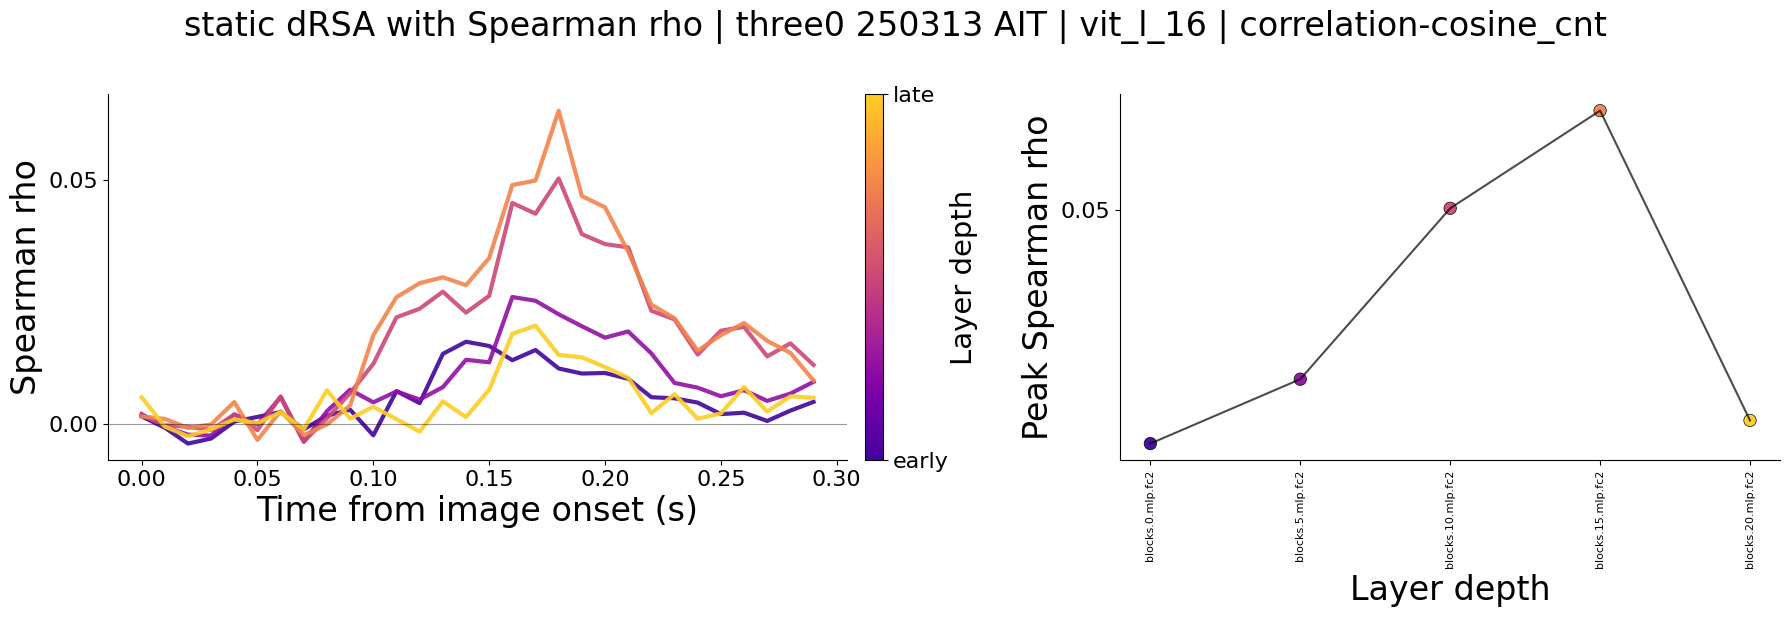

In [28]:
fig, (ax_time, ax_depth) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [1.35, 1]})
cmap = truncate_colormap(mpl.colormaps[cfg.cmap_name])
norm = mpl.colors.Normalize(vmin=0, vmax=len(layers) - 1)

for layer_idx, layer_name in enumerate(layers):
    if layer_name not in spearman_curves:
        continue
    curve = spearman_curves[layer_name]
    t = np.arange(curve.size) / cfg.new_fs
    ax_time.plot(
        t,
        curve,
        color=cmap(norm(layer_idx)),
        linewidth=cfg.line_width,
        alpha=cfg.alpha,
        label=layer_name,
    )

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax_time, pad=0.02)
cbar.set_ticks([0, len(layers) - 1])
cbar.set_ticklabels(["early", "late"], fontsize=cfg.ticksize)
cbar.set_label("Layer depth", fontsize=cfg.ticksize + 5, labelpad=1)

ax_time.axhline(0, color="black", linewidth=0.8, alpha=0.4)
ax_time.set_xlabel("Time from image onset (s)", fontsize=cfg.labelsize)
ax_time.set_ylabel("Spearman rho", fontsize=cfg.labelsize)
ax_time.tick_params(axis="both", labelsize=cfg.ticksize)
ax_time.spines[["top", "right"]].set_visible(False)
ax_time.yaxis.set_major_locator(ticker.MultipleLocator(0.05))

depths = []
peak_similarities = []
depth_labels = []
for layer_idx, layer_name in enumerate(layers):
    if layer_name not in spearman_curves:
        continue
    depths.append(layer_idx)
    peak_similarities.append(np.nanmax(spearman_curves[layer_name]))
    depth_labels.append(layer_name)

ax_depth.plot(depths, peak_similarities, color="black", linewidth=1.5, alpha=0.7)
ax_depth.scatter(
    depths,
    peak_similarities,
    c=depths,
    cmap=cmap,
    norm=norm,
    s=80,
    edgecolor="black",
    linewidth=0.5,
    alpha=0.95,
)
ax_depth.set_xlabel("Layer depth", fontsize=cfg.labelsize)
ax_depth.set_ylabel("Peak Spearman rho", fontsize=cfg.labelsize)
ax_depth.tick_params(axis="both", labelsize=cfg.ticksize)
ax_depth.set_xticks(depths)
ax_depth.set_xticklabels(depth_labels, rotation=90, fontsize=max(cfg.ticksize - 8, 8))
ax_depth.spines[["top", "right"]].set_visible(False)
ax_depth.yaxis.set_major_locator(ticker.MultipleLocator(0.05))

fig.suptitle(
    f"static dRSA with Spearman rho | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name} | {metric_label}",
    fontsize=cfg.labelsize,
    y=1.02,
)
plt.tight_layout()
plt.show()

## Optional Pearson comparison

loaded existing Pearson curves: 5 / 5


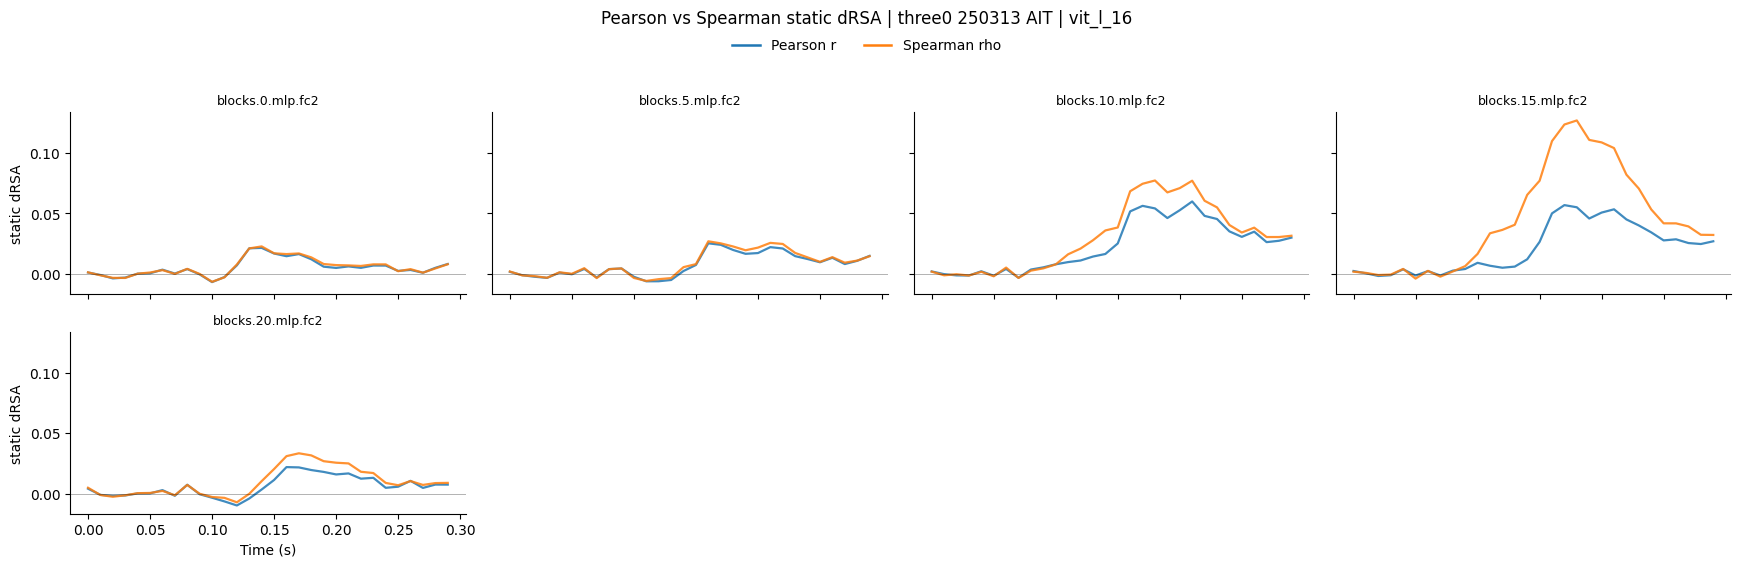

In [59]:
pearson_curves = {}
if cfg.compare_to_existing_pearson:
    for layer_name in layers:
        save_name = static_drsa_save_name(layer_name, RSA_metric=cfg.pearson_RSA_metric)
        if save_name.exists():
            pearson_curves[layer_name] = np.load(save_name)["arr_0"]
    print(f"loaded existing Pearson curves: {len(pearson_curves)} / {len(layers)}")
else:
    print("Pearson comparison disabled")

common_layers = [layer_name for layer_name in layers if layer_name in spearman_curves and layer_name in pearson_curves]
if common_layers:
    n_cols = 4
    n_rows = int(np.ceil(len(layers) / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(4.4 * n_cols, 2.8 * n_rows),
        sharex=True,
        sharey=True,
    )
    axes = np.asarray(axes).ravel()

    for layer_idx, layer_name in enumerate(layers):
        ax = axes[layer_idx]
        if layer_name not in common_layers:
            ax.text(0.5, 0.5, "missing", transform=ax.transAxes, ha="center", va="center")
            ax.set_title(layer_name, fontsize=9)
            ax.spines[["top", "right"]].set_visible(False)
            continue

        spearman_curve = spearman_curves[layer_name]
        pearson_curve = pearson_curves[layer_name]
        n = min(spearman_curve.size, pearson_curve.size)
        t = np.arange(n) / cfg.new_fs
        ax.plot(t, pearson_curve[:n], color="tab:blue", linewidth=1.6, alpha=0.85)
        ax.plot(t, spearman_curve[:n], color="tab:orange", linewidth=1.6, alpha=0.85)
        ax.axhline(0, color="black", linewidth=0.6, alpha=0.35)
        ax.set_title(layer_name, fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)

    for ax in axes[len(layers):]:
        ax.axis("off")

    for ax in axes[-n_cols:]:
        ax.set_xlabel("Time (s)")
    for ax in axes[::n_cols]:
        ax.set_ylabel("static dRSA")

    legend_handles = [
        mpl.lines.Line2D([0], [0], color="tab:blue", linewidth=1.8, label="Pearson r"),
        mpl.lines.Line2D([0], [0], color="tab:orange", linewidth=1.8, label="Spearman rho"),
    ]
    fig.legend(handles=legend_handles, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 0.975), ncol=2)
    fig.suptitle(
        f"Pearson vs Spearman static dRSA | {cfg.monkey_name} {cfg.date} {cfg.brain_area} | {cfg.model_name}",
        y=1.005,
    )
    plt.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()
else:
    print("No common Pearson/Spearman layers to plot.")